# Exploratory Data Analysis — ZICER Hackathon 2026
Four datasets: **Clients**, **Products**, **Transactions**, **Product Balances**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('dataRaw')

## 1. Load data

In [4]:
def parse_date(s):
    """Handle format like '5/3/2025/ 13:06:52' (trailing slash after year)."""
    s = s.str.strip().str.replace(r'(\d{4})/', r'\1', regex=True)
    return pd.to_datetime(s, format='%d/%m/%Y %H:%M:%S', errors='coerce')

def parse_date_only(s):
    """Handle date-only format like '1/3/2007/'."""
    s = s.str.strip().str.replace(r'(\d{4})/', r'\1', regex=True)
    return pd.to_datetime(s, format='%d/%m/%Y', errors='coerce')

def read_csv(name):
    if name == 'HACKATHON ZICER 202604 TRANSAKCIJE.csv':
        cols = [
            'IDENTIFIKATOR_PROIZVODA', 'DATUM_I_VRIJEME_TRANSAKCIJE', 'IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI',
            'VALUTA_TRANSAKCIJE', 'KANAL', 'SMJER', 'DRZAVA_DRUGE_STRANE', 'DJELATNOST_DRUGE_STRANE',
            'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE', 'VRSTA_TRANSAKCIJE'
        ]
        df = pd.read_csv(DATA / name, sep=';', encoding='latin-1', 
                         names=cols + ['EXTRA'], header=0, low_memory=False)
        mask = df['EXTRA'].notna()
        df.loc[mask, 'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'] = df.loc[mask, 'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'] + ';' + df.loc[mask, 'VRSTA_TRANSAKCIJE']
        df.loc[mask, 'VRSTA_TRANSAKCIJE'] = df.loc[mask, 'EXTRA']
        df = df.drop(columns=['EXTRA'])
        return df
    else:
        return pd.read_csv(DATA / name, sep=';', encoding='latin-1', low_memory=False)


clients  = read_csv('HACKATHON ZICER 202604 KLIJENTI.csv')
products = read_csv('HACKATHON ZICER 202604 PROIZVODI.csv')
tx       = read_csv('HACKATHON ZICER 202604 TRANSAKCIJE.csv')
balances = read_csv('HACKATHON ZICER 202604 STANJA PROIZVODA.csv')

# Parse timestamps
tx['DATUM_I_VRIJEME_TRANSAKCIJE'] = parse_date(tx['DATUM_I_VRIJEME_TRANSAKCIJE'])

for col in ['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA', 'DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA']:
    clients[col] = parse_date_only(clients[col])

for col in ['DATUM_OTVARANJA', 'DATUM_ZATVARANJA']:
    products[col] = parse_date_only(products[col])

# Parse numeric amount (comma decimal separator)
tx['IZNOS'] = tx['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'].astype(str).str.replace(',', '.').pipe(pd.to_numeric, errors='coerce')
balances['STANJE_DOM'] = balances['STANJE_U_DOMICILNOJ_VALUTI'].astype(str).str.replace(',', '.').pipe(pd.to_numeric, errors='coerce')

print(f'Clients:  {clients.shape}')
print(f'Products: {products.shape}')
print(f'Txns:     {tx.shape}')
print(f'Balances: {balances.shape}')

Clients:  (11997, 38)
Products: (58703, 13)
Txns:     (1187661, 11)
Balances: (817933, 7)


## 2. Schema overview

In [5]:
for name, df in [('KLIJENTI', clients), ('PROIZVODI', products), ('TRANSAKCIJE', tx), ('STANJA', balances)]:
    print(f'\n=== {name} ===')
    print(df.dtypes.to_string())
    print(f'Nulls:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string()}')


=== KLIJENTI ===
IDENTIFIKATOR_KLIJENTA                            object
DOB                                                int64
GRAD_STALNE_ADRESE                                object
POSTANSKI_BROJ_STALNE_ADRESE                      object
ZUPANIJA_STALNE_ADRESE                            object
DRZAVA_STALNE_ADRESE                              object
STATISTICKA_OZNAKA                                object
ORGANIZACIJSKA_JEDINICA_KLIJENTA                   int64
DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA      datetime64[ns]
DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA    datetime64[ns]
SPOL                                              object
STATUS_ZAPOSLENJA                                 object
VRSTA_ZAPOSLENJA                                  object
POZICIJA                                          object
STRUCNA_SPREMA                                    object
SIFRA_VRSTE_KLIJENTA                               int64
DRZAVA_NACIONALNOSTI                              object
GRAD_DOPISNE_

## 3. Clients EDA

In [6]:
clients.head(3)

,IDENTIFIKATOR_KLIJENTA,DOB,GRAD_STALNE_ADRESE,POSTANSKI_BROJ_STALNE_ADRESE,ZUPANIJA_STALNE_ADRESE,DRZAVA_STALNE_ADRESE,STATISTICKA_OZNAKA,ORGANIZACIJSKA_JEDINICA_KLIJENTA,DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA,DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA,...,KATEGORIJA_POSLODAVCA,TIP_POSLODAVCA,VRSTA_STANOVANJA,PERIOD_PROVEDEN_NA_TRENUTNOJ_ADRESI,TIP_VLASNISTVA,BROJ_CLANOVA_KUCANSTVA,BROJ_UZDRZAVANIH_CLANOVA_KUCANSTVA,KLIJENT_PREMINUO,BRACNI_STATUS,KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI
0,WHSUM7XXA9Z0,37,ZAGREB,10000,GRAD ZAGREB,HRVATSKA,60000015 - OSTALE FIZIÈKE OSOBE,249,2007-03-01,2007-03-01,...,NaN,OSTALO,NaN,NaN,NaN,NaN,NaN,N,NaN,NE
1,WGMCLGEREI1L,60,ABICA,53000,LIÈKO-SENJSKA UPANIJA,HRVATSKA,60000015 - OSTALE FIZIÈKE OSOBE,201,2007-08-13,2007-08-13,...,NaN,JAVNO PODUZEÆE,VLASTITI STAN/KUÆA,>5,NaN,NaN,NaN,N,Y,NE
2,53NHZ40D7ZK3,75,RIJEKA,51000,PRIMORSKO-GORANSKA UPANIJA,HRVATSKA,60000015 - OSTALE FIZIÈKE OSOBE,256,2006-04-29,2006-04-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NE


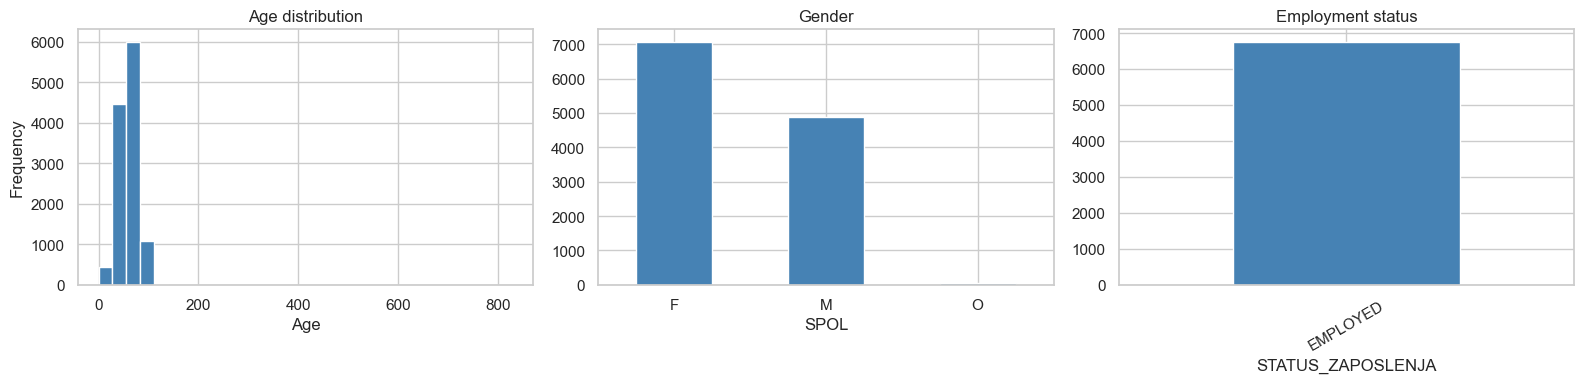

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
clients['DOB'].dropna().plot.hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

# Gender
clients['SPOL'].value_counts().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Gender')
axes[1].tick_params(axis='x', rotation=0)

# Employment status
clients['STATUS_ZAPOSLENJA'].value_counts().plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('Employment status')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

/var/folders/zn/kwwpw8d5773232__xbr6ncdr0000gp/T/ipykernel_44671/3116624153.py:12: UserWarning: Glyph 142 (\x8e) missing from font(s) Arial.
  plt.tight_layout()
/Users/Max/.pyenv/versions/tf/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 142 (\x8e) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


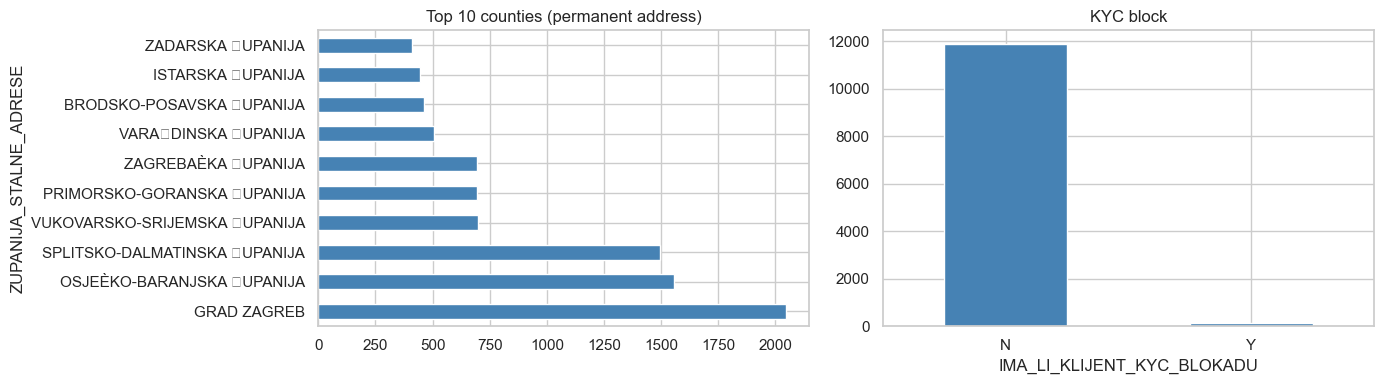

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top counties
clients['ZUPANIJA_STALNE_ADRESE'].value_counts().head(10).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 counties (permanent address)')

# KYC block
clients['IMA_LI_KLIJENT_KYC_BLOKADU'].value_counts().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('KYC block')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

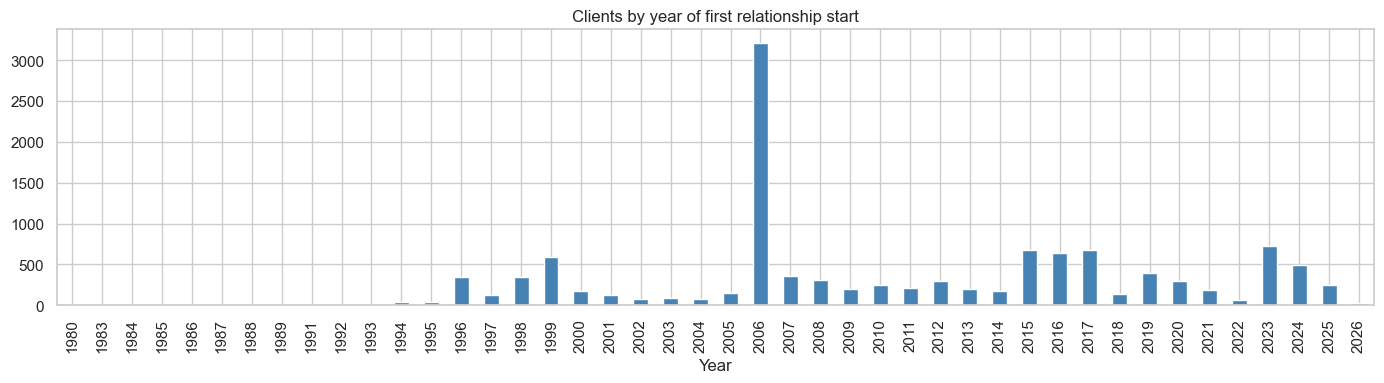

In [9]:
# Client relationship start year
clients['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'].dt.year.value_counts().sort_index().plot.bar(figsize=(14,4), color='steelblue')
plt.title('Clients by year of first relationship start')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## 4. Products EDA

In [10]:
products.head(3)

,IDENTIFIKATOR_KLIJENTA,IDENTIFIKATOR_PROIZVODA,VALUTA_PROIZVODA,NAZIV_DOMENE_PROIZVODA,NAZIV_KATEGORIJE_PROIZVODA,NAZIV_KLASE_PROIZVODA,NAZIV_GRUPE_PROIZVODA,SIFRA_VRSTE_PROIZVODA,NAZIV_VRSTE_PROIZVODA,NAZIV_PROIZVODA,DATUM_OTVARANJA,DATUM_ZATVARANJA,STATUS_KARTICE
0,ZSA4IXNUCFXL,SI4Q8KQLNEK4OASXHHVS8CPF9PI9ZY,HRK,RAÈUNI,TRANSAKCIJSKI RAÈUN,TEKUÆI RAÈUN,DEPOZITI PO VIÐENJU,SA001,TEKUÆI RAÈUN,TEKUÆI RAÈUN,1997-05-08,2023-01-01,NaN
1,GPFBM8FDUEPP,ZMK4N24NEFUZDXVXJ6R3LABZA18MZ8,HRK,RAÈUNI,TRANSAKCIJSKI RAÈUN,TEKUÆI RAÈUN,DEPOZITI PO VIÐENJU,SA001,TEKUÆI RAÈUN,TEKUÆI RAÈUN,2008-03-18,2023-01-01,NaN
2,NSNUYIZ7EB72,JP87I86TY6CBG9Q398M0T3JAX9OTQN,HRK,RAÈUNI,TRANSAKCIJSKI RAÈUN,TEKUÆI RAÈUN,DEPOZITI PO VIÐENJU,SA001,TEKUÆI RAÈUN,TEKUÆI RAÈUN,2008-10-17,2023-01-01,NaN


/var/folders/zn/kwwpw8d5773232__xbr6ncdr0000gp/T/ipykernel_44671/1084649140.py:9: UserWarning: Glyph 138 (\x8a) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zn/kwwpw8d5773232__xbr6ncdr0000gp/T/ipykernel_44671/1084649140.py:9: UserWarning: Glyph 142 (\x8e) missing from font(s) Arial.
  plt.tight_layout()
/Users/Max/.pyenv/versions/tf/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 138 (\x8a) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/Max/.pyenv/versions/tf/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 142 (\x8e) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


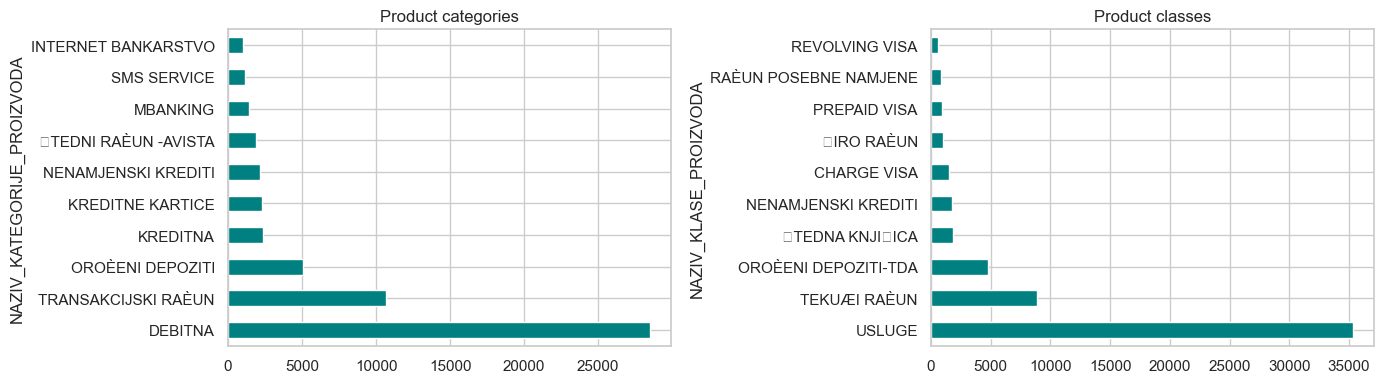

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

products['NAZIV_KATEGORIJE_PROIZVODA'].value_counts().head(10).plot.barh(ax=axes[0], color='teal')
axes[0].set_title('Product categories')

products['NAZIV_KLASE_PROIZVODA'].value_counts().head(10).plot.barh(ax=axes[1], color='teal')
axes[1].set_title('Product classes')

plt.tight_layout()
plt.show()

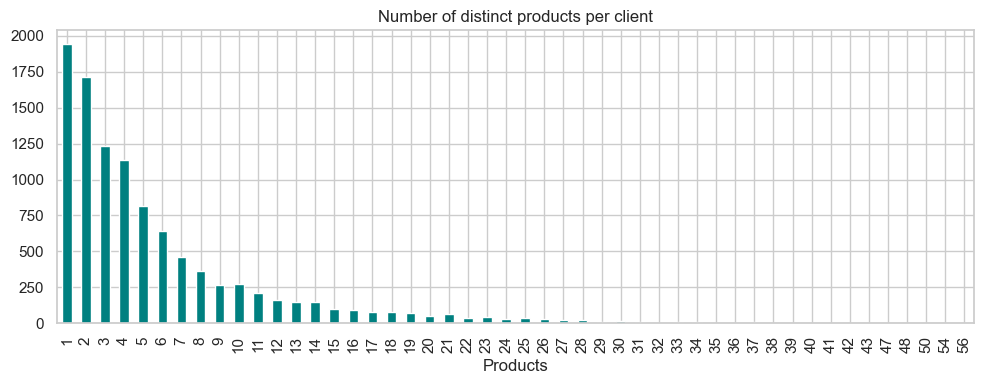

count    10336.000000
mean         5.679470
std          5.847664
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         56.000000
Name: IDENTIFIKATOR_PROIZVODA, dtype: float64


In [12]:
# Products per client
prods_per_client = products.groupby('IDENTIFIKATOR_KLIJENTA')['IDENTIFIKATOR_PROIZVODA'].nunique()
prods_per_client.value_counts().sort_index().plot.bar(color='teal', figsize=(10,4))
plt.title('Number of distinct products per client')
plt.xlabel('Products')
plt.tight_layout()
plt.show()
print(prods_per_client.describe())

## 5. Transactions EDA

In [13]:
tx.head(3)

,IDENTIFIKATOR_PROIZVODA,DATUM_I_VRIJEME_TRANSAKCIJE,IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI,VALUTA_TRANSAKCIJE,KANAL,SMJER,DRZAVA_DRUGE_STRANE,DJELATNOST_DRUGE_STRANE,KATEGORIJA_DJELATNOSTI_DRUGE_STRANE,VRSTA_TRANSAKCIJE,IZNOS
OON4MDVUFBSD12L4870U9WS90D6JRB,8/5/2025/ 14:06:05,NaT,EUR,BANK,C,HR,OPÆE DJELATNOSTI JAVNE UPRAVE ...,JAVNA UPRAVA I OBRANA,OBVEZNO SOCIJALNO OSIGURANJE,OSTALO,NaN
FX8QUVJ5EIEBDR84U8UOZ4DK2W6QAZ,5/3/2025/ 13:06:52,NaT,EUR,BANK,C,HR,DJELATNOSTI SOCIJALNE SKRBI BEZ SMJETAJA ZA S...,DJELATNOSTI ZDRAVSTVENE ZATITE I SOCIJALNE SKRBI,OSTALO,NaN,NaN
FX8QUVJ5EIEBDR84U8UOZ4DK2W6QAZ,5/3/2026/ 15:41:37,NaT,EUR,BANK,C,HR,DJELATNOSTI SOCIJALNE SKRBI BEZ SMJETAJA ZA S...,DJELATNOSTI ZDRAVSTVENE ZATITE I SOCIJALNE SKRBI,OSTALO,NaN,NaN


In [14]:
print('Amount stats (EUR):')
print(tx['IZNOS'].describe().apply(lambda x: f'{x:,.2f}'))

Amount stats (EUR):
count    0.00
mean      nan
std       nan
min       nan
25%       nan
50%       nan
75%       nan
max       nan
Name: IZNOS, dtype: object


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Direction
tx['SMJER'].value_counts().plot.bar(ax=axes[0], color='coral')
axes[0].set_title('Transaction direction (C=credit, D=debit)')
axes[0].tick_params(axis='x', rotation=0)

# Channel
tx['KANAL'].value_counts().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Channel')
axes[1].tick_params(axis='x', rotation=30)

# Transaction type
tx['VRSTA_TRANSAKCIJE'].value_counts().head(10).plot.barh(ax=axes[2], color='coral')
axes[2].set_title('Transaction type (top 10)')

plt.tight_layout()
plt.show()

In [ ]:
# Amount distribution (log scale, capped at 99th percentile)
cap = tx['IZNOS'].quantile(0.99)
tx['IZNOS'].clip(upper=cap).plot.hist(bins=60, color='coral', figsize=(10, 4))
plt.title(f'Transaction amount distribution (capped at 99th pct = {cap:,.0f} EUR)')
plt.xlabel('Amount (EUR)')
plt.tight_layout()
plt.show()

In [ ]:
# Top industries of counterparty
tx['KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'].str.strip().value_counts().head(12).plot.barh(color='coral', figsize=(12, 5))
plt.title('Top counterparty industry categories')
plt.tight_layout()
plt.show()

## 6. Transaction Timespan & Frequency

In [ ]:
ts = tx['DATUM_I_VRIJEME_TRANSAKCIJE'].dropna().sort_values()

start = ts.min()
end   = ts.max()
span  = end - start

print(f'Earliest transaction : {start}')
print(f'Latest transaction   : {end}')
print(f'Total timespan       : {span.days} days ({span.days/365.25:.1f} years)')
print(f'Total transactions   : {len(ts):,}')
print(f'Avg per day          : {len(ts)/span.days:.1f}')

In [ ]:
# Daily transaction count
daily = tx.set_index('DATUM_I_VRIJEME_TRANSAKCIJE').resample('D')['IZNOS'].count().rename('count')

fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title('Daily transaction count')
plt.xlabel('Date')
plt.ylabel('Number of transactions')
plt.tight_layout()
plt.show()

In [ ]:
# Monthly transaction count and total volume
monthly = tx.set_index('DATUM_I_VRIJEME_TRANSAKCIJE').resample('ME')[['IZNOS']].agg(
    count=('IZNOS', 'count'),
    volume=('IZNOS', 'sum')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

monthly['count'].plot.bar(ax=axes[0], color='steelblue', width=0.8)
axes[0].set_title('Monthly transaction count')
axes[0].set_ylabel('Count')

monthly['volume'].plot.bar(ax=axes[1], color='coral', width=0.8)
axes[1].set_title('Monthly transaction volume (EUR)')
axes[1].set_ylabel('Volume (EUR)')

# Format x-axis labels
labels = [t.strftime('%Y-%m') if hasattr(t, 'strftime') else str(t) for t in monthly.index]
for ax in axes:
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Hour-of-day and day-of-week patterns
tx['hour'] = tx['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.hour
tx['dow']  = tx['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.day_name()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tx['hour'].value_counts().sort_index().plot.bar(ax=axes[0], color='mediumseagreen')
axes[0].set_title('Transactions by hour of day')
axes[0].set_xlabel('Hour')

tx['dow'].value_counts().reindex(dow_order).plot.bar(ax=axes[1], color='mediumseagreen')
axes[1].set_title('Transactions by day of week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Transactions per account (product)
tx_per_product = tx.groupby('IDENTIFIKATOR_PROIZVODA').size()
print('Transactions per product account:')
print(tx_per_product.describe().apply(lambda x: f'{x:,.1f}'))

tx_per_product.clip(upper=tx_per_product.quantile(0.99)).plot.hist(bins=40, color='steelblue', figsize=(10,4))
plt.title('Transactions per account (capped at 99th pct)')
plt.xlabel('Number of transactions')
plt.tight_layout()
plt.show()

## 7. Product Balances EDA

In [ ]:
balances.head(3)

In [ ]:
print('Balance stats (domestic currency):')
print(balances['STANJE_DOM'].describe().apply(lambda x: f'{x:,.2f}'))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Balance type distribution
balances['TIP_STANJA'].value_counts().plot.bar(ax=axes[0], color='purple')
axes[0].set_title('Balance type')
axes[0].tick_params(axis='x', rotation=30)

# Balance distribution (log, capped)
cap = balances['STANJE_DOM'].quantile(0.99)
balances['STANJE_DOM'].clip(lower=0, upper=cap).plot.hist(bins=50, ax=axes[1], color='purple')
axes[1].set_title(f'Balance distribution (capped at 99th pct = {cap:,.0f})')

plt.tight_layout()
plt.show()

## 8. Cross-dataset joins

In [ ]:
# Join transactions -> products -> clients
tx_prod = tx.merge(products[['IDENTIFIKATOR_KLIJENTA','IDENTIFIKATOR_PROIZVODA','NAZIV_KATEGORIJE_PROIZVODA']],
                   on='IDENTIFIKATOR_PROIZVODA', how='left')

tx_full = tx_prod.merge(clients[['IDENTIFIKATOR_KLIJENTA','DOB','SPOL','ZUPANIJA_STALNE_ADRESE']],
                        on='IDENTIFIKATOR_KLIJENTA', how='left')

print(f'Joined dataset shape: {tx_full.shape}')
print(f'Match rate: {tx_full["IDENTIFIKATOR_KLIJENTA"].notna().mean():.1%}')

In [ ]:
# Avg transaction amount by gender
tx_full.groupby('SPOL')['IZNOS'].mean().sort_values().plot.bar(color='steelblue', figsize=(8,4))
plt.title('Average transaction amount by gender')
plt.ylabel('EUR')
plt.tight_layout()
plt.show()

In [ ]:
# Transaction volume by age bucket
tx_full['age_bucket'] = pd.cut(tx_full['DOB'], bins=[0,25,35,45,55,65,100],
                                labels=['<25','25-35','35-45','45-55','55-65','65+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tx_full.groupby('age_bucket', observed=True)['IZNOS'].count().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Transaction count by age group')
axes[0].tick_params(axis='x', rotation=0)

tx_full.groupby('age_bucket', observed=True)['IZNOS'].mean().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Avg transaction amount by age group (EUR)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Debit vs credit volume by product category
pivot = tx_full.groupby(['NAZIV_KATEGORIJE_PROIZVODA','SMJER'])['IZNOS'].sum().unstack(fill_value=0)
pivot.plot.barh(figsize=(12,6), colormap='coolwarm')
plt.title('Transaction volume (EUR) by product category and direction')
plt.tight_layout()
plt.show()